#Data 205 Capstone Project: Exploring NFL Statistics
------------------------------------------------------------------------

##Intoduction
###Libraries and Datasets

------------------------------------------------------------------------


This project will be utilizing several libraries, including the main libraries such as: Numpy, Pandas, Matplotlib, and Seaborn for visualizations, as well as Sklearn and Stats.models for linear regression tests. The main group of datasets for analysis will be the ‘Stats’ datasets, with the ‘Drives’, ‘Scoring’, and ‘Season’ datasets will be used for extra analysis and added context.

In [1]:
#pip install nflreadpy

In [2]:
#import nflreadpy as nfl
#from datetime import datetime

In [3]:
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
stats_2023 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2023.csv')
stats_2022 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2022.csv')
stats_2021 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2021.csv')
stats_2020 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2020.csv')
stats_2019 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Stats-2019.csv')

In [6]:
stats = pd.concat((stats_2023, stats_2022, stats_2021, stats_2020, stats_2019))
stats.tail()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_tds,pass_cmp,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
529,2019,2020-01-19,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,27,112,2,23,...,61,27,6,10,0.600,1,1,1.000,1790,https://www.pro-football-reference.com/boxscor...
530,2019,2020-01-19,D5QY6bOxfn8ZL,Green Bay,Packers,GB,16,62,1,31,...,46,21,3,9,0.333,2,2,1.000,1873,https://www.pro-football-reference.com/boxscor...
531,2019,2020-01-19,IwSI92ZDKoazn,San Francisco,49ers,SF,42,285,4,6,...,10,19,4,10,0.400,0,0,0.000,1727,https://www.pro-football-reference.com/boxscor...
532,2019,2020-02-02,IwSI92ZDKoazn,San Francisco,49ers,SF,22,141,1,20,...,45,21,3,8,0.375,0,1,0.000,1607,https://www.pro-football-reference.com/boxscor...
533,2019,2020-02-02,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,29,129,2,26,...,24,26,6,14,0.429,2,3,0.667,1993,https://www.pro-football-reference.com/boxscor...


In [7]:
#Add Column named "rush_avg"
rush_avg = stats['rush_yds'] / stats['rush_att']
stats.insert(8, 'rush_avg', rush_avg)
stats.head()


,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_avg,rush_tds,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
0,2023,2024-01-28,zyhFXj1nywrm1,Baltimore,Ravens,BAL,16,81,5.062500,0,...,95,16,3,11,0.273,2,2,1.000,1350,https://www.pro-football-reference.com/boxscor...
1,2023,2024-01-28,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,32,89,2.781250,1,...,30,22,8,18,0.444,1,2,0.500,2250,https://www.pro-football-reference.com/boxscor...
2,2023,2024-01-28,IwSI92ZDKoazn,San Francisco,49ers,SF,33,155,4.696970,3,...,20,23,6,12,0.500,0,1,0.000,1932,https://www.pro-football-reference.com/boxscor...
3,2023,2024-01-28,FCuH1wdksA2DQ,Detroit,Lions,DET,29,182,6.275862,3,...,15,28,6,12,0.500,1,3,0.333,1668,https://www.pro-football-reference.com/boxscor...
4,2023,2024-01-21,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,24,146,6.083333,1,...,15,21,1,5,0.200,0,0,0.000,1377,https://www.pro-football-reference.com/boxscor...


In [8]:
#add Column named "rush_success"
rush_td_per_att = stats['rush_tds'] / stats['rush_att']
fumbles_lost_per_att = stats['fumbles_lost'] / stats['rush_att']
rush_success = stats['rush_avg'] + (4 * rush_td_per_att) - (4 * fumbles_lost_per_att)
stats.insert(9, 'rush_success', rush_success)
stats.head()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_avg,rush_success,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
0,2023,2024-01-28,zyhFXj1nywrm1,Baltimore,Ravens,BAL,16,81,5.062500,4.562500,...,95,16,3,11,0.273,2,2,1.000,1350,https://www.pro-football-reference.com/boxscor...
1,2023,2024-01-28,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,32,89,2.781250,2.906250,...,30,22,8,18,0.444,1,2,0.500,2250,https://www.pro-football-reference.com/boxscor...
2,2023,2024-01-28,IwSI92ZDKoazn,San Francisco,49ers,SF,33,155,4.696970,5.060606,...,20,23,6,12,0.500,0,1,0.000,1932,https://www.pro-football-reference.com/boxscor...
3,2023,2024-01-28,FCuH1wdksA2DQ,Detroit,Lions,DET,29,182,6.275862,6.551724,...,15,28,6,12,0.500,1,3,0.333,1668,https://www.pro-football-reference.com/boxscor...
4,2023,2024-01-21,oiGiwWPf0UqMC,Kansas City,Chiefs,KC,24,146,6.083333,6.083333,...,15,21,1,5,0.200,0,0,0.000,1377,https://www.pro-football-reference.com/boxscor...


In [9]:
rush_success

,0
0,4.562500
1,2.906250
2,5.060606
3,6.551724
4,6.083333
...,...
529,4.444444
530,3.875000
531,7.166667
532,6.590909


In [11]:
#Create dataframes for Rushing Stats for each year
rushing_2019 = stats_2019[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds', 'rush_success', 'fumbles', 'fumbles_lost']]
rushing_2020 = stats_2020[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds', 'rush_success', 'fumbles', 'fumbles_lost']]
rushing_2021 = stats_2021[['name', 'rush_att', 'rush_yds', 'rush_avg','rush_tds', 'rush_success', 'fumbles', 'fumbles_lost']]
rushing_2022 = stats_2022[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds', 'rush_success', 'fumbles', 'fumbles_lost']]
rushing_2023 = stats_2023[['name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds', 'rush_success', 'fumbles', 'fumbles_lost']]
rushing_total = stats[['season', 'name', 'rush_att', 'rush_yds', 'rush_avg', 'rush_tds', 'rush_success', 'fumbles', 'fumbles_lost']]
rushing_total.head()

,season,name,rush_att,rush_yds,rush_avg,rush_tds,rush_success,fumbles,fumbles_lost
0,2023,Ravens,16,81,5.062500,0,4.562500,2,2
1,2023,Chiefs,32,89,2.781250,1,2.906250,2,0
2,2023,49ers,33,155,4.696970,3,5.060606,0,0
3,2023,Lions,29,182,6.275862,3,6.551724,1,1
4,2023,Chiefs,24,146,6.083333,1,6.083333,2,1


In [14]:
#add Column named "pass_avg"
pass_avg = stats['pass_yds'] / stats['pass_cmp']
stats.insert(15, 'pass_avg', pass_avg)
stats.head()

ValueError: cannot insert pass_avg, already exists

In [17]:
#Create dataframes for Passing stats for each year
passing_2019 = stats_2019[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2020 = stats_2020[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2021 = stats_2021[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2022 = stats_2022[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2023 = stats_2023[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_total = stats[['name', 'pass_att', 'pass_cmp', 'pass_avg', 'pass_tds', 'pass_int', 'passer_rating', 'net_pass_yds', 'times_sacked', 'yds_sacked_for']]
passing_2019.head()

,name,pass_att,pass_cmp,pass_avg,pass_tds,pass_int,passer_rating,net_pass_yds,times_sacked,yds_sacked_for
0,Packers,30,18,11.277778,1,0,91.389,166,5,37
1,Bears,45,26,8.769231,0,1,62.083,208,5,20
2,Falcons,46,33,9.212121,2,2,85.779,272,4,32
3,Vikings,10,8,12.250000,1,0,140.833,97,1,1
4,Bills,37,24,10.583333,1,2,71.227,242,1,12


In [16]:
stats_2019 = stats[stats['season'] == 2019]
stats_2020 = stats[stats['season'] == 2020]
stats_2021 = stats[stats['season'] == 2021]
stats_2022 = stats[stats['season'] == 2022]
stats_2023 = stats[stats['season'] == 2023]
stats_2019.head()

,season,event_date,nano,market,name,alias,rush_att,rush_yds,rush_avg,rush_success,...,penalty_yds,first_downs,third_down_conv,third_down_att,third_down_conv_pct,fourth_down_conv,fourth_down_att,fourth_down_conv_pct,time_of_possession,boxscore_stats_link
0,2019,2019-09-05,D5QY6bOxfn8ZL,Green Bay,Packers,GB,22,47,2.136364,2.136364,...,71,13,2,12,0.167,0,0,0.0,1863,https://www.pro-football-reference.com/boxscor...
1,2019,2019-09-05,1vVmWGzUZ1rea,Chicago,Bears,CHI,15,46,3.066667,3.066667,...,107,16,3,15,0.200,0,2,0.0,1737,https://www.pro-football-reference.com/boxscor...
2,2019,2019-09-08,mLspw4gJNTQGN,Atlanta,Falcons,ATL,17,73,4.294118,4.058824,...,78,27,2,8,0.250,2,2,1.0,1813,https://www.pro-football-reference.com/boxscor...
3,2019,2019-09-08,AzOs5UWsXusSW,Minnesota,Vikings,MIN,38,172,4.526316,4.842105,...,100,18,5,10,0.500,0,0,0.0,1787,https://www.pro-football-reference.com/boxscor...
4,2019,2019-09-08,3VqeLK0LS9rpw,Buffalo,Bills,BUF,25,128,5.120000,4.960000,...,55,23,5,10,0.500,0,1,0.0,1679,https://www.pro-football-reference.com/boxscor...


In [18]:
scoring_2019 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Scoring-2019.csv')
scoring_2020 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Scoring-2020.csv')
scoring_2021 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Scoring-2021.csv')
scoring_2022 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Scoring-2022.csv')
scoring_2023 = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Scoring-2023.csv')
scoring_2019.head()

,season,event_date,tm_nano,tm_market,tm_name,tm_alias,opp_nano,opp_market,opp_name,opp_alias,quarter,time,scoring_team,tm_score,opp_score,description,boxscore_stats_link
0,2019,2019-09-05,1vVmWGzUZ1rea,Chicago,Bears,CHI,D5QY6bOxfn8ZL,Green Bay,Packers,GB,1.0,249,Bears,3,0,Eddy Pineiro 38 yard field goal,https://www.pro-football-reference.com/boxscor...
1,2019,2019-09-05,1vVmWGzUZ1rea,Chicago,Bears,CHI,D5QY6bOxfn8ZL,Green Bay,Packers,GB,2.0,788,Packers,3,7,Jimmy Graham 8 yard pass from Aaron Rodgers (M...,https://www.pro-football-reference.com/boxscor...
2,2019,2019-09-05,1vVmWGzUZ1rea,Chicago,Bears,CHI,D5QY6bOxfn8ZL,Green Bay,Packers,GB,4.0,315,Packers,3,10,Mason Crosby 39 yard field goal,https://www.pro-football-reference.com/boxscor...
3,2019,2019-09-08,AzOs5UWsXusSW,Minnesota,Vikings,MIN,mLspw4gJNTQGN,Atlanta,Falcons,ATL,1.0,710,Vikings,7,0,Adam Thielen 23 yard pass from Kirk Cousins (D...,https://www.pro-football-reference.com/boxscor...
4,2019,2019-09-08,AzOs5UWsXusSW,Minnesota,Vikings,MIN,mLspw4gJNTQGN,Atlanta,Falcons,ATL,1.0,502,Vikings,14,0,Dalvin Cook 19 yard rush (Dan Bailey kick),https://www.pro-football-reference.com/boxscor...


In [19]:
drives_full = pd.read_csv('https://raw.githubusercontent.com/JordanBaker78/Data205_JordanBaker/refs/heads/main/Project_Datasets/Drives(in).csv')
drives = drives_full[drives_full['season'] != 2018]
drives_2019 = drives[drives['season'] == 2019]
drives_2020 = drives[drives['season'] == 2020]
drives_2021 = drives[drives['season'] == 2021]
drives_2022 = drives[drives['season'] == 2022]
drives_2023 = drives[drives['season'] == 2023]
drives_full.tail()

,season,tm_market,tm_name,tm_alias,opp_nano,opp_market,opp_name,opp_alias,tm_on_offense,tm_on_defense,...,net_yards,penalties,pass_plays,rush_plays,total_plays,points,drive_start,drive_end,clean,boxscore_stats_link
32456,2018,New England,Patriots,NE,hjjmgzxilGWdr,Philadelphia,Eagles,PHI,NE,PHI,...,48,0,4,1,5,0,Kickoff,End of Half,1,https://www.pro-football-reference.com/boxscor...
32457,2018,New England,Patriots,NE,hjjmgzxilGWdr,Philadelphia,Eagles,PHI,PHI,NE,...,67,1,9,4,14,3,Kickoff,Field Goal,1,https://www.pro-football-reference.com/boxscor...
32458,2018,New England,Patriots,NE,hjjmgzxilGWdr,Philadelphia,Eagles,PHI,NE,PHI,...,67,1,6,2,9,3,Kickoff,Field Goal,1,https://www.pro-football-reference.com/boxscor...
32459,2018,New England,Patriots,NE,hjjmgzxilGWdr,Philadelphia,Eagles,PHI,PHI,NE,...,77,0,2,1,3,7,Kickoff,Touchdown,1,https://www.pro-football-reference.com/boxscor...
32460,2018,New England,Patriots,NE,hjjmgzxilGWdr,Philadelphia,Eagles,PHI,NE,PHI,...,74,1,3,4,8,0,Kickoff,Missed FG,1,https://www.pro-football-reference.com/boxscor...


In [20]:
#forty_niners_2019 = stats_2019[stats_2019['name'] == '49ers']
#forty_niners_total_rush_2019 = forty_niners_2019['rush_yds'].sum()

all_teams_total_rush_2019 = stats_2019.groupby('name')['rush_yds'].sum().reset_index()
#print("Total Rushing Yards for 49ers in 2019:", forty_niners_total_rush_2019)
print("\nTotal Rushing Yards for All Teams in 2019:")
print(all_teams_total_rush_2019.to_string())


Total Rushing Yards for All Teams in 2019:
             name  rush_yds
0           49ers      2917
1           Bears      1458
2         Bengals      1517
3           Bills      2226
4         Broncos      1662
5          Browns      1901
6      Buccaneers      1521
7       Cardinals      1990
8        Chargers      1453
9          Chiefs      1928
10          Colts      2130
11        Cowboys      2153
12       Dolphins      1156
13         Eagles      2059
14        Falcons      1361
15  Football Team      1583
16         Giants      1685
17        Jaguars      1708
18           Jets      1257
19          Lions      1649
20        Packers      1966
21       Panthers      1819
22       Patriots      1801
23        Raiders      1893
24           Rams      1499
25         Ravens      3481
26         Saints      1835
27       Seahawks      2374
28       Steelers      1447
29         Texans      2244
30         Titans      2726
31        Vikings      2290


In [21]:
all_teams_total_rush_2020 = stats_2020.groupby('name')['rush_yds'].sum().reset_index()
all_teams_total_rush_2021 = stats_2021.groupby('name')['rush_yds'].sum().reset_index()
all_teams_total_rush_2022 = stats_2022.groupby('name')['rush_yds'].sum().reset_index()
all_teams_total_rush_2023 = stats_2023.groupby('name')['rush_yds'].sum().reset_index()

In [ ]:
print(all_teams_total_rush_2019.to_string())

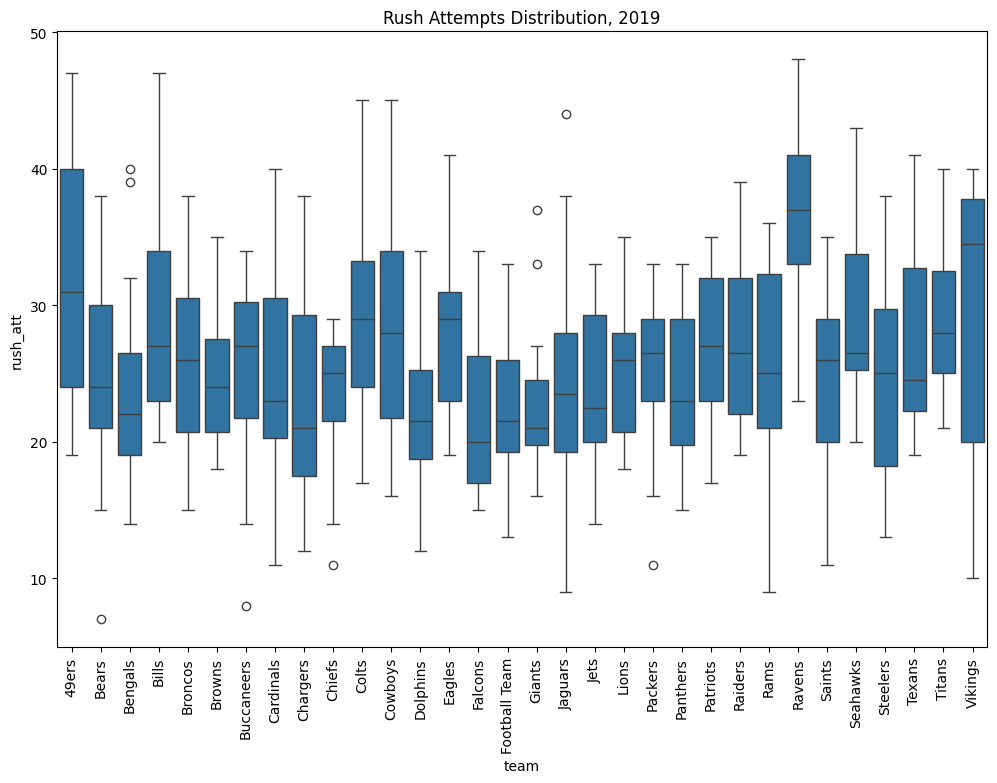

In [23]:
#Plot that shows the distribution of rushing atts by team for the 2019 season
plt.figure(figsize=(12, 8))
sns.boxplot(data=rushing_2019.sort_values(by='name'), x="name", y="rush_att")
plt.title("Rush Attempts Distribution, 2019")
plt.xlabel('team')
plt.xticks(rotation=90)
plt.show()

This boxplot simply shows rushing attempts per game by team in the 2019 season. There is a lot of variation in the distribution but the median is between 20 and 30 rushing attempts for nearly every team. The biggest outlier is the Ravens who have a median of over 35 rushing attempts per game and didn't have a game with less than 25 attempts. The following plots will diplay the same for the following seasons.

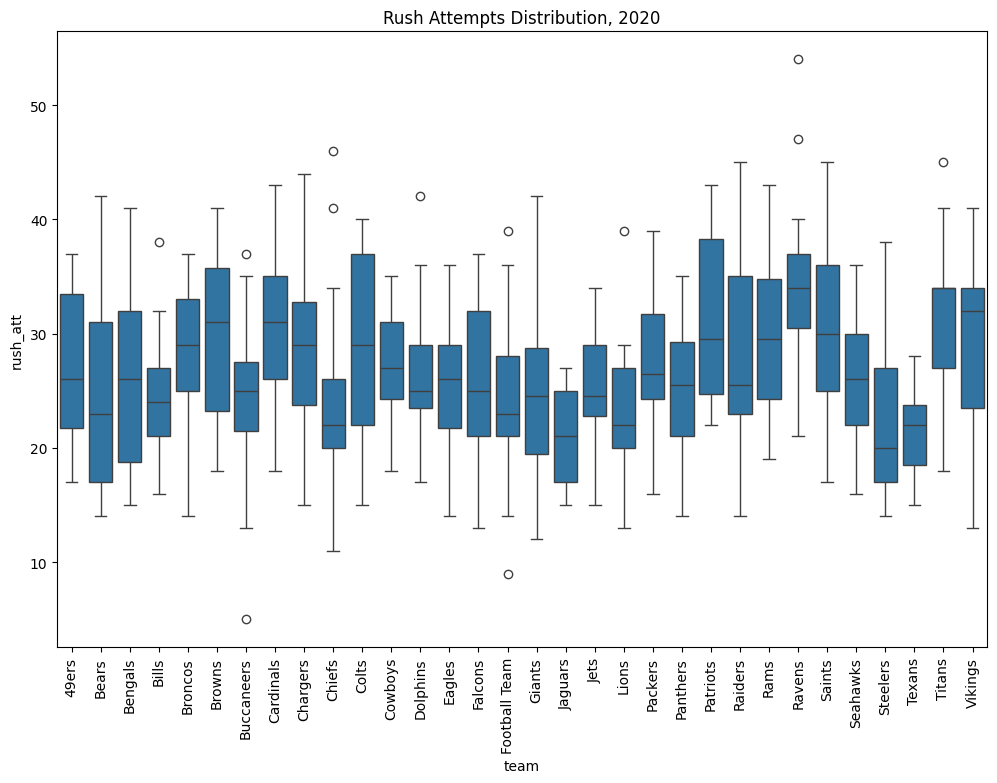

In [24]:
#Plot that shows the distribution of rushing atts by team for the 2020 season
plt.figure(figsize=(12, 8))
sns.boxplot(data=rushing_2020.sort_values(by='name'), x="name", y="rush_att")
plt.title("Rush Attempts Distribution, 2020")
plt.xlabel('team')
plt.xticks(rotation=90)
plt.show()

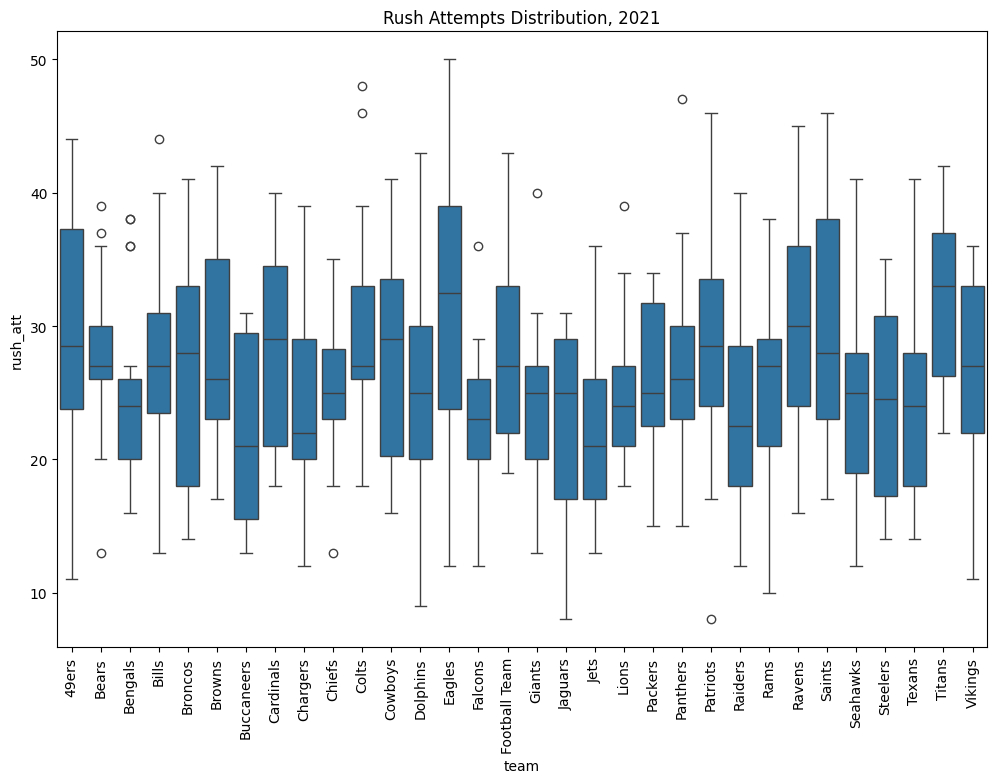

In [25]:
#Plot that shows the distribution of rushing atts by team for the 2021 season
plt.figure(figsize=(12, 8))
sns.boxplot(data=rushing_2021.sort_values(by='name'), x="name", y="rush_att")
plt.title("Rush Attempts Distribution, 2021")
plt.xticks(rotation=90)
plt.xlabel('team')
plt.show()

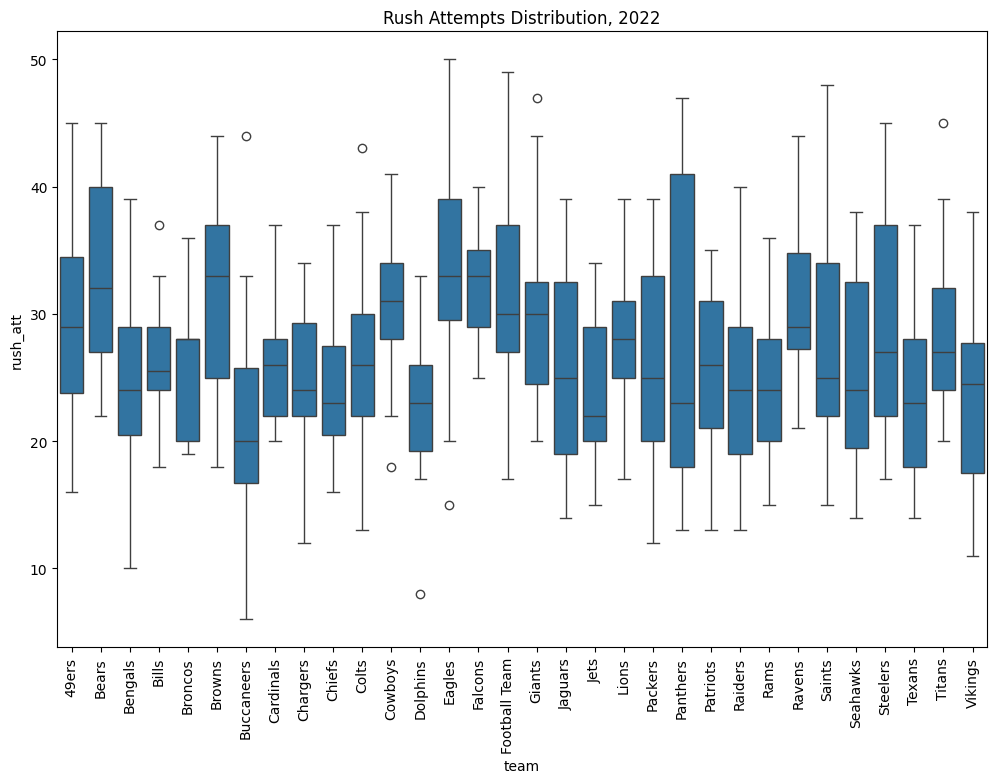

In [26]:
#Plot that shows the distribution of rushing atts by team for the 2022 season
plt.figure(figsize=(12, 8))
sns.boxplot(data=rushing_2022.sort_values(by='name'), x="name", y="rush_att")
plt.title("Rush Attempts Distribution, 2022")
plt.xticks(rotation=90)
plt.xlabel('team')
plt.show()

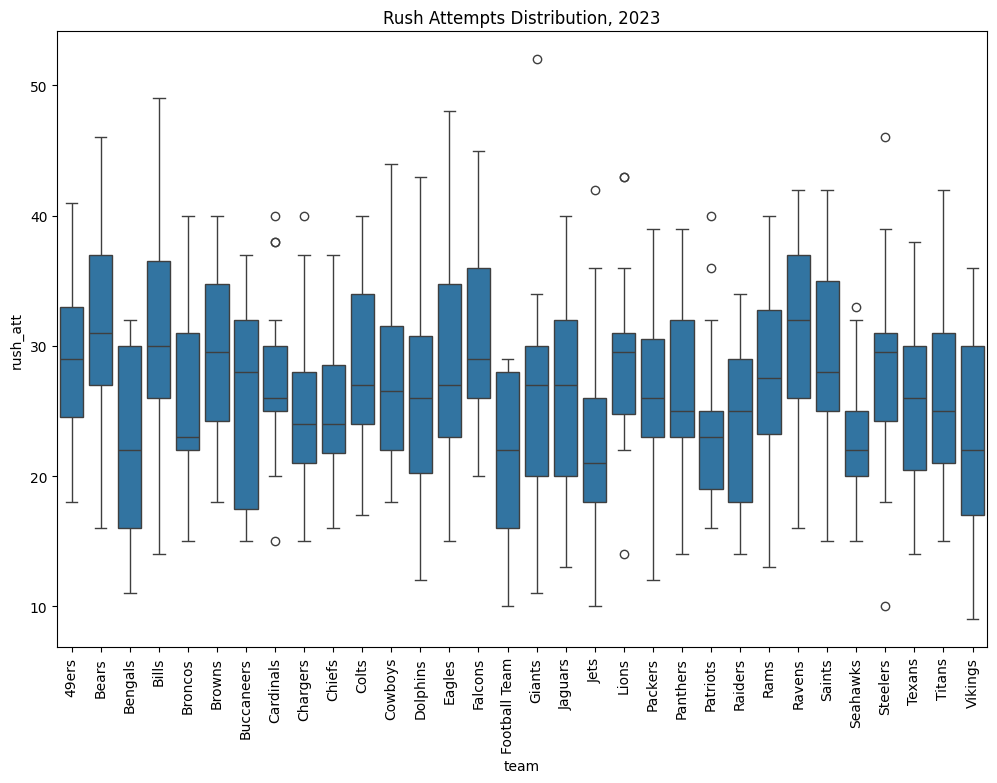

In [27]:
#Plot that shows the distribution of rushing atts by team for the 2023 season
plt.figure(figsize=(12, 8))
sns.boxplot(data=rushing_2023.sort_values(by='name'), x="name", y="rush_att")
plt.title("Rush Attempts Distribution, 2023")
plt.xticks(rotation=90)
plt.xlabel('team')
plt.show()

These plots likley won't make the final presentation, but it is interesting to note a couple things:
 - The overall spread for each team is always quite different from year to year, but the differences in the spread from 2020 and 2021 looks the most significant. The teams' overall spread appears much tighter in 2020, then balloons the following season. I have no idea what the cause for that could be.
 - The 2019 plot displays the gap between the Ravens and everyone else, showing their record breaking rushing season. They didn't have a game under 20 rushing attempts and had a game of almost 50(!!) attempts, showing their absolute dominance in the running game that season.
 - The Ravens, while not being the absolute best every season, have been in the top ten for every season that is displayed here, likley due to Lamar Jackson, who is already hailed as the greatest rushing QB of all time.

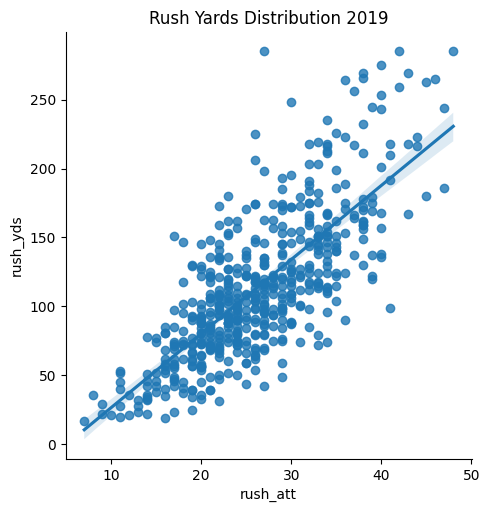

In [28]:
#Plot shows rush atts vs rush yards 2019
sns.lmplot(data=rushing_2019, x="rush_att", y="rush_yds", height= 5, aspect= 1)
plt.title("Rush Yards Distribution 2019")
plt.show()

This plot shows the distribution of rushing yards per attempt (rush average) for every single game in the 2019 season. We can see that the relationship is very linear. The following plots will diplay the data from the other seasons.

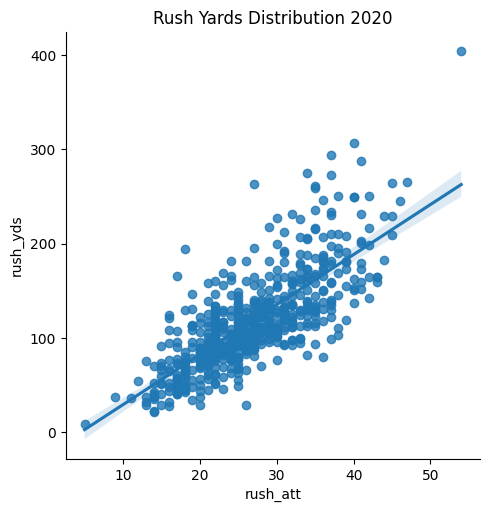

In [29]:
#Plot shows rush atts vs rush yards 2020
sns.lmplot(data=rushing_2020, x="rush_att", y="rush_yds", height= 5, aspect= 1)
plt.title("Rush Yards Distribution 2020")
plt.show()

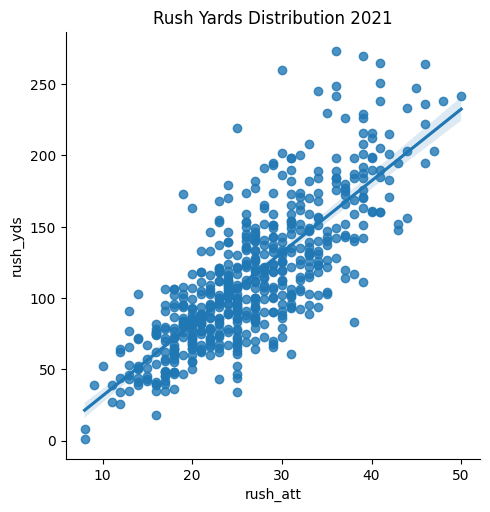

In [30]:
#Plot shows rush atts vs rush yards 2021
sns.lmplot(data=rushing_2021, x="rush_att", y="rush_yds", height= 5, aspect= 1)
plt.title("Rush Yards Distribution 2021")
plt.show()

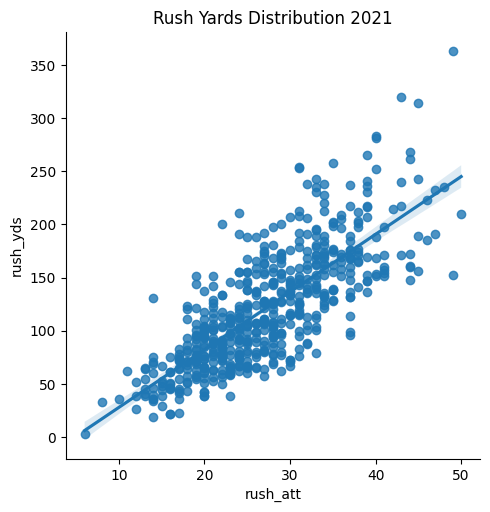

In [31]:
#Plot shows rush atts vs rush yards 2022
sns.lmplot(data=rushing_2022, x="rush_att", y="rush_yds", height= 5, aspect= 1)
plt.title("Rush Yards Distribution 2021")
plt.show()

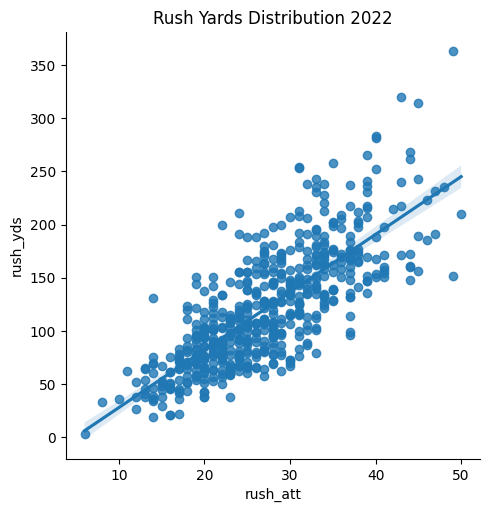

In [32]:
#Plot shows rush atts vs rush yards 2022
sns.lmplot(data=rushing_2022, x="rush_att", y="rush_yds", height= 5, aspect= 1)
plt.title("Rush Yards Distribution 2022")
plt.show()

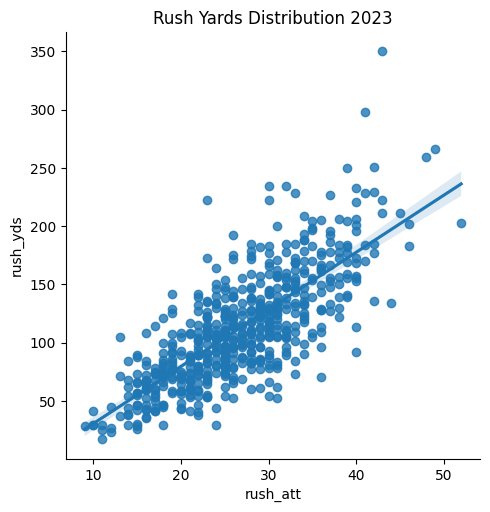

In [33]:
#Plot shows rush atts vs rush yards 2023
sns.lmplot(data=rushing_2023, x="rush_att", y="rush_yds", height= 5, aspect= 1)
plt.title("Rush Yards Distribution 2023")
plt.show()

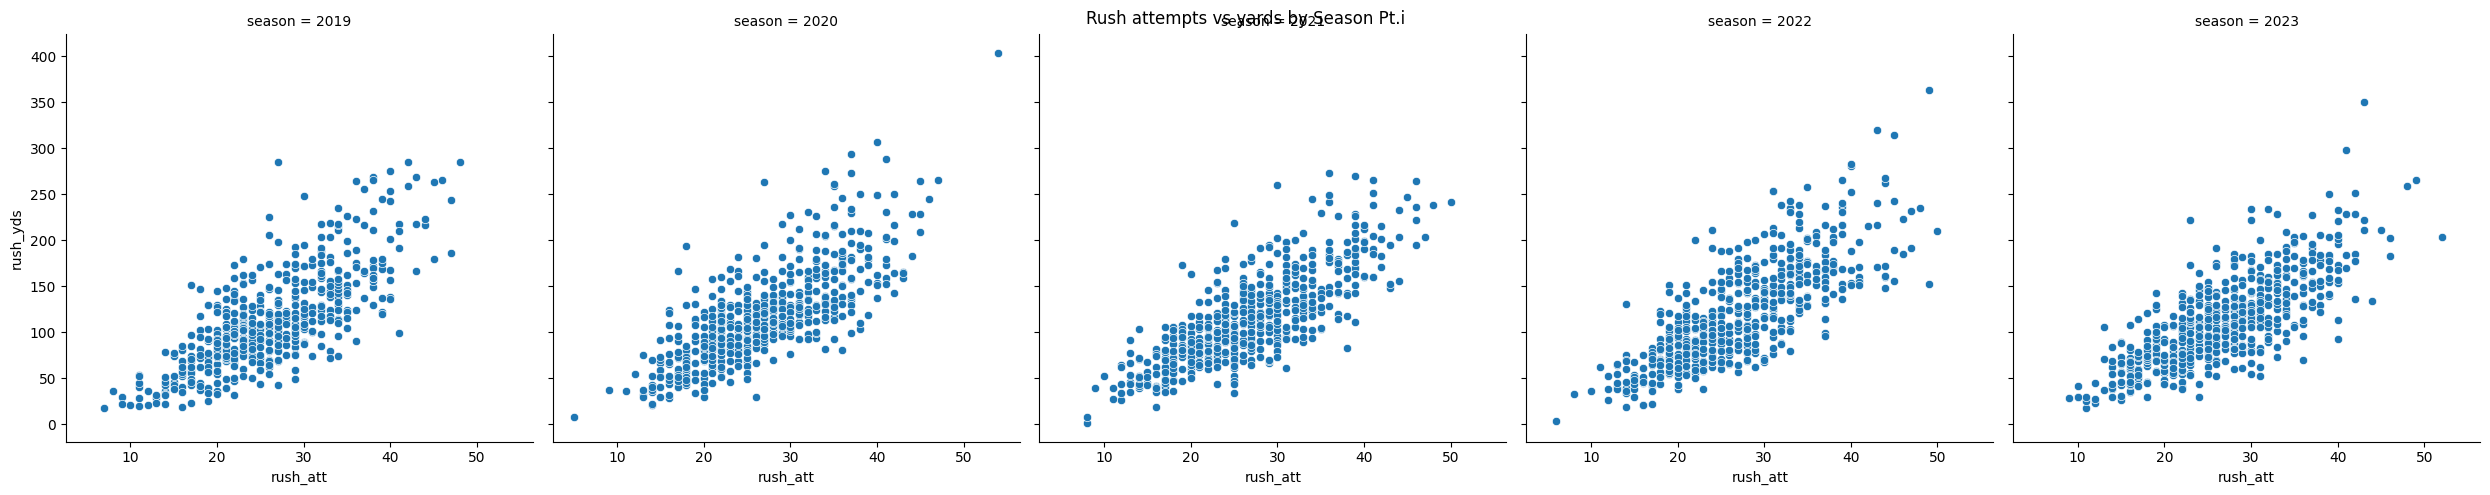

In [34]:
#Plot to show rushing distribution (attemps vs yards) sperated by season
sns.relplot(data=rushing_total, x="rush_att", y="rush_yds", col="season")
plt.suptitle("Rush attempts vs yards by Season Pt.i")
plt.show()
##I think this might be the coolest visulization so far.

This (group of) plot(s) shows that there is not a big differnce in the running game from season to season. The distribution is extremly similar across each season.

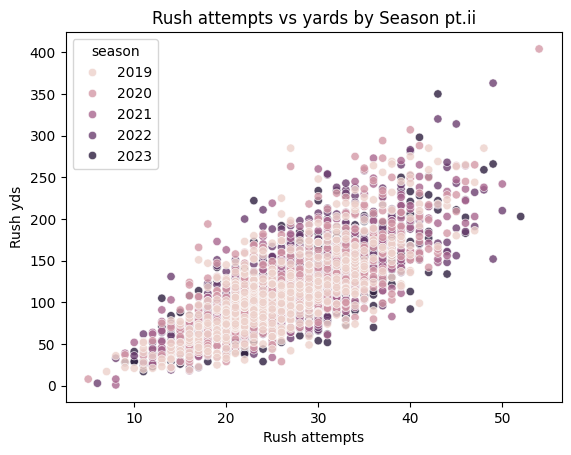

In [35]:
sns.scatterplot(data=stats, x="rush_att", y="rush_yds", hue = "season", alpha = 0.8)
plt.title("Rush attempts vs yards by Season pt.ii")
plt.xlabel("Rush attempts")
plt.ylabel("Rush yds")
plt.show()

This plot also shows the distribution of attempts vs yds, just on one plot and it also shows the similarities across each season.

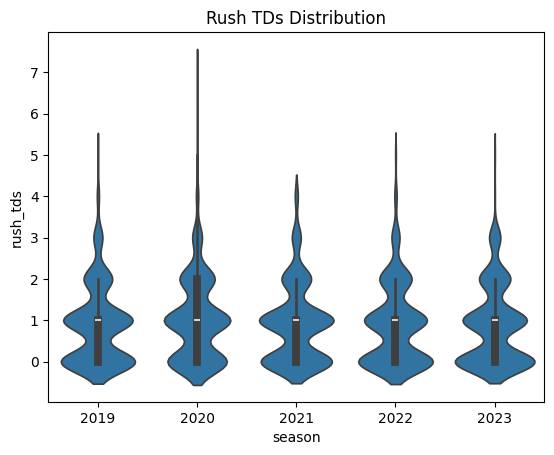

In [36]:
#violin plot (x = 'season', y = rushing (atts, yds, tds) vs. passing (atts, yds, tds))

sns.violinplot(data=stats, x="season", y="rush_tds")
plt.title("Rush TDs Distribution")
plt.show()

This violin plot shows the ddistribuion of rushing touchdowns in a game per season. The distributions appear to be very similar, with the biggest outlier being one game with 7 rushing touchdowns. The average rushing tds in a game is 1 for every season, which is quite interesting.

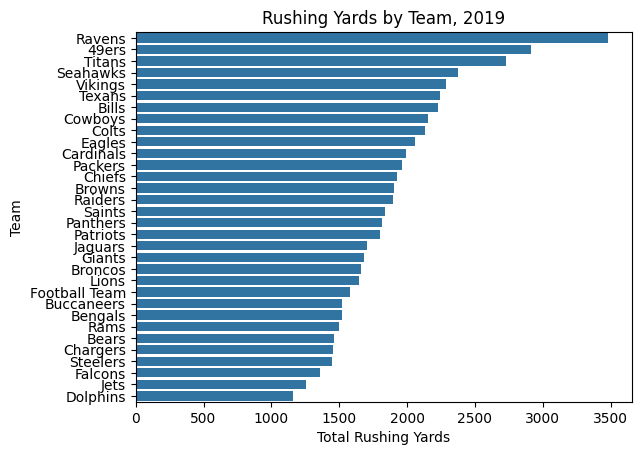

In [37]:
#Horizontal barchart that displays total rushing yards by team for the 2019 season
sns.barplot(data = all_teams_total_rush_2019.sort_values(by='rush_yds', ascending=False), x = 'rush_yds', y = 'name')
plt.title("Rushing Yards by Team, 2019")
plt.xlabel('Total Rushing Yards')
plt.ylabel('Team')
plt.show()

This plot shows total rushing yards by team for the 2019 season. This will go well with the boxplots that will add more conext to the rushing game for each team in each season. The following plots will display the following seasons.

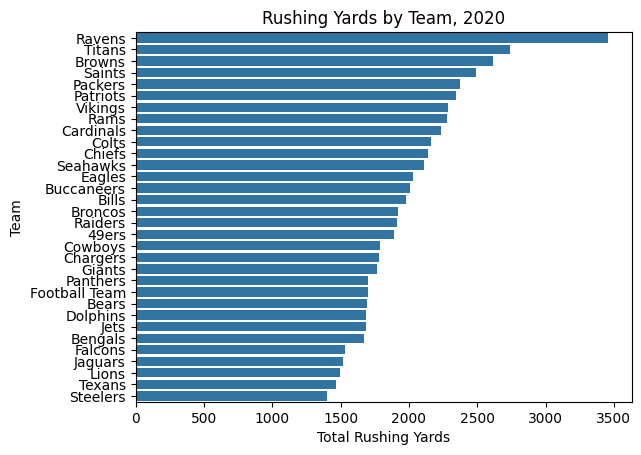

In [38]:
#Horizontal barchart that displays total rushing yards by team for the 2020 season
sns.barplot(data = all_teams_total_rush_2020.sort_values(by='rush_yds', ascending=False), x = 'rush_yds', y = 'name')
plt.title("Rushing Yards by Team, 2020")
plt.xlabel('Total Rushing Yards')
plt.ylabel('Team')
plt.show()

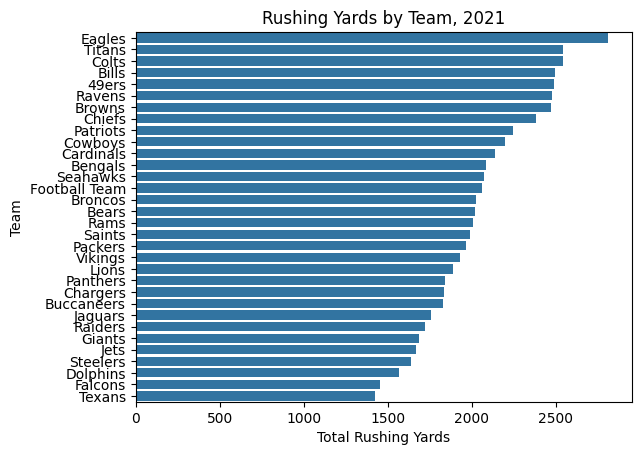

In [39]:
#Horizontal barchart that displays total rushing yards by team for the 2021 season
sns.barplot(data = all_teams_total_rush_2021.sort_values(by='rush_yds', ascending=False), x = 'rush_yds', y = 'name')
plt.title("Rushing Yards by Team, 2021")
plt.xlabel('Total Rushing Yards')
plt.ylabel('Team')
plt.show()

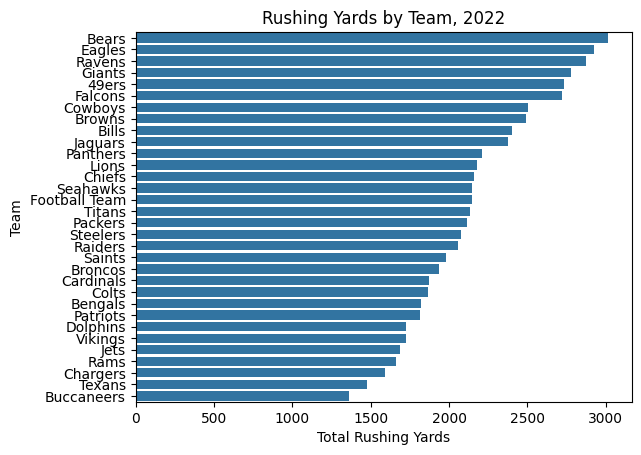

In [40]:
#Horizontal barchart that displays total rushing yards by team for the 2022 season
sns.barplot(data = all_teams_total_rush_2022.sort_values(by='rush_yds', ascending=False), x = 'rush_yds', y = 'name')
plt.title("Rushing Yards by Team, 2022")
plt.xlabel('Total Rushing Yards')
plt.ylabel('Team')
plt.show()

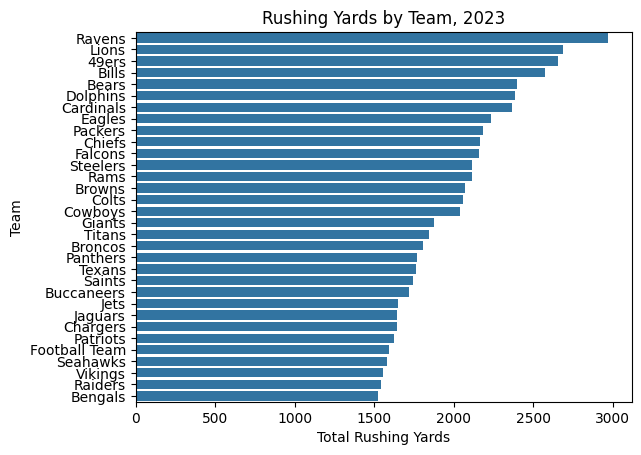

In [41]:
#Horizontal barchart that displays total rushing yards by team for the 2023 season
sns.barplot(data = all_teams_total_rush_2023.sort_values(by='rush_yds', ascending=False), x = 'rush_yds', y = 'name')
plt.title("Rushing Yards by Team, 2023")
plt.xlabel('Total Rushing Yards')
plt.ylabel('Team')
plt.show()

As we said before, we can see that the Ravens are always top five and are the #1 rushing team 3 out of the five years. Based on the data we can see that the Ravens are undoubtlbly the best rushing team of this era. Their record breaking year had them almost reach 3500 rushing yards and they did it again the following season as well. (Also important to mention that Lamar Jackson broke the single season rushing record for a QB in that 2019 season as well.)

Another team with rushing success is the Titans who was top 3 in total rushing yards from 2019 to 2021, before falling to medicority the next two seasons. Their success was largely due to Derrick Henr who led the league in rushing in 2019 and 2020, before getting injured halway through the 2021 season. But what's crazy is, Henry had nearly eclipsed 1000 yards (the benchmark for rushing yards) in only 8 games (!!), leading the league in yds/game for a 3rd straight year and leading the Titans to 2nd in the league for total team rushing yards despite playing only half the season. It is interesting to note though, that despite, a fully healthy Derrick Henry the next two seasons, and him having the second most yards in both seasons, the Titans only ranked league average for total team rushing yards, which goes to show, that one superstar running back is not all you need for team success.

Some other notable teams include:
 - The 49ers who ranked in the top 5 for 4 out of the 5 seasons.
 - The Texans who ranked 6th in 2019, then ranked 31st, 32nd, and 31st the following seasons.
 - The Eagles are consistently top ten, while the Buccaneers are consistently bottom ten, despite both teams winning a Super Bowl in this era.

 One other thing that I found interesting from this group of graphs is 2021 was the only year where no team reached 3000 total rushing yards. That year also had the least rushing tds as well.

In [42]:
all_teams_rush_success_2019 = stats_2019.groupby('name')['rush_success'].mean().reset_index()
all_teams_rush_success_2020 = stats_2020.groupby('name')['rush_success'].mean().reset_index()
all_teams_rush_success_2021 = stats_2021.groupby('name')['rush_success'].mean().reset_index()
all_teams_rush_success_2022 = stats_2022.groupby('name')['rush_success'].mean().reset_index()
all_teams_rush_success_2023 = stats_2023.groupby('name')['rush_success'].mean().reset_index()
print(all_teams_rush_success_2019.sort_values(by='rush_success', ascending=False).to_string())

             name  rush_success
25         Ravens      5.677782
30         Titans      5.005486
5          Browns      4.931191
0           49ers      4.890653
7       Cardinals      4.796604
21       Panthers      4.701115
29         Texans      4.666341
11        Cowboys      4.638386
26         Saints      4.588693
16         Giants      4.570246
3           Bills      4.560273
27       Seahawks      4.521452
9          Chiefs      4.403217
10          Colts      4.390462
23        Raiders      4.374296
20        Packers      4.308948
15  Football Team      4.299461
13         Eagles      4.239348
31        Vikings      4.236007
17        Jaguars      4.124593
4         Broncos      4.119730
19          Lions      3.984584
22       Patriots      3.951842
6      Buccaneers      3.854812
8        Chargers      3.761915
24           Rams      3.733692
14        Falcons      3.681541
2         Bengals      3.670083
28       Steelers      3.589823
1           Bears      3.522407
18      

In [43]:
print(all_teams_total_rush_2019.sort_values(by='rush_yds', ascending=False).to_string())

             name  rush_yds
25         Ravens      3481
0           49ers      2917
30         Titans      2726
27       Seahawks      2374
31        Vikings      2290
29         Texans      2244
3           Bills      2226
11        Cowboys      2153
10          Colts      2130
13         Eagles      2059
7       Cardinals      1990
20        Packers      1966
9          Chiefs      1928
5          Browns      1901
23        Raiders      1893
26         Saints      1835
21       Panthers      1819
22       Patriots      1801
17        Jaguars      1708
16         Giants      1685
4         Broncos      1662
19          Lions      1649
15  Football Team      1583
6      Buccaneers      1521
2         Bengals      1517
24           Rams      1499
1           Bears      1458
8        Chargers      1453
28       Steelers      1447
14        Falcons      1361
18           Jets      1257
12       Dolphins      1156


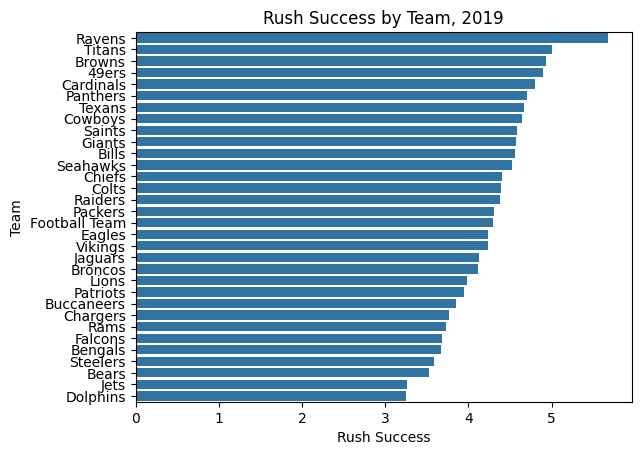

In [44]:
#barplot that shows rush sucess by team for the 2019 season
sns.barplot(data = all_teams_rush_success_2019.sort_values(by='rush_success', ascending=False), x = 'rush_success', y = 'name')
plt.title("Rush Success by Team, 2019")
plt.xlabel('Rush Success')
plt.ylabel('Team')
plt.show()

This plot gives a better picture of how successful each teams running game was in 2019 as opposed to who just had the most total yards. The 'rush_success' variable is a metric composed from a formula that includes, yards per attempt ('rush_avg), touchdowns per attempt, and fumbles per attempt. Everything is on a 'per attempt' baisis so we can see how each team performed *on average*. The following plots will display each teams rush success for the following seasons.

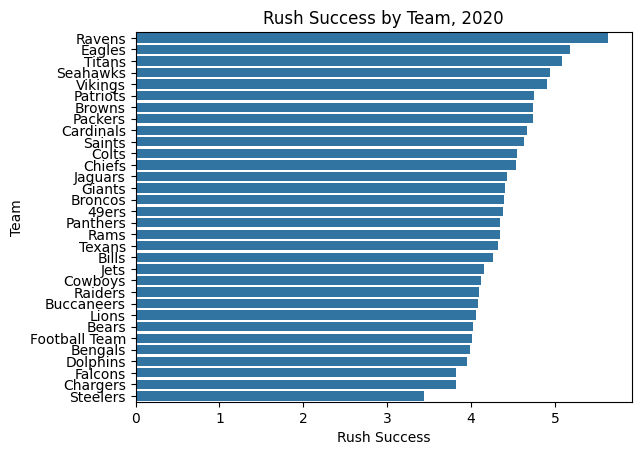

In [45]:
#barplot that shows rush sucess by team for the 2020 season
sns.barplot(data = all_teams_rush_success_2020.sort_values(by='rush_success', ascending=False), x = 'rush_success', y = 'name')
plt.title("Rush Success by Team, 2020")
plt.xlabel('Rush Success')
plt.ylabel('Team')
plt.show()

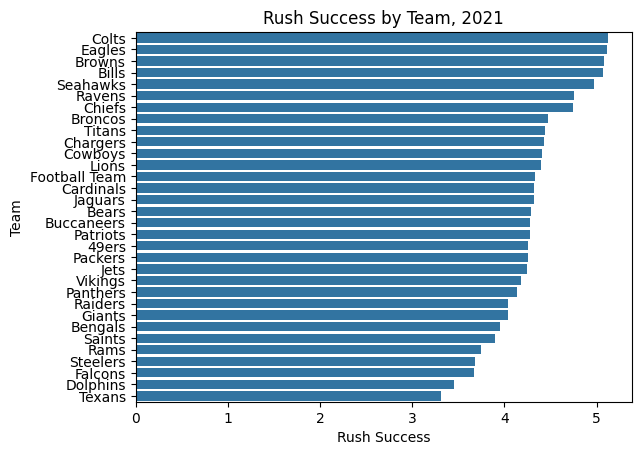

In [46]:
#barplot that shows rush sucess by team for the 2021 season
sns.barplot(data = all_teams_rush_success_2021.sort_values(by='rush_success', ascending=False), x = 'rush_success', y = 'name')
plt.title("Rush Success by Team, 2021")
plt.xlabel('Rush Success')
plt.ylabel('Team')
plt.show()

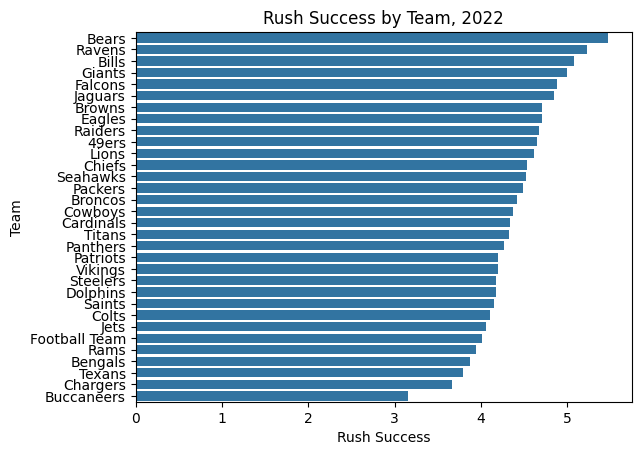

In [47]:
#barplot that shows rush sucess by team for the 2022 season
sns.barplot(data = all_teams_rush_success_2022.sort_values(by='rush_success', ascending=False), x = 'rush_success', y = 'name')
plt.title("Rush Success by Team, 2022")
plt.xlabel('Rush Success')
plt.ylabel('Team')
plt.show()

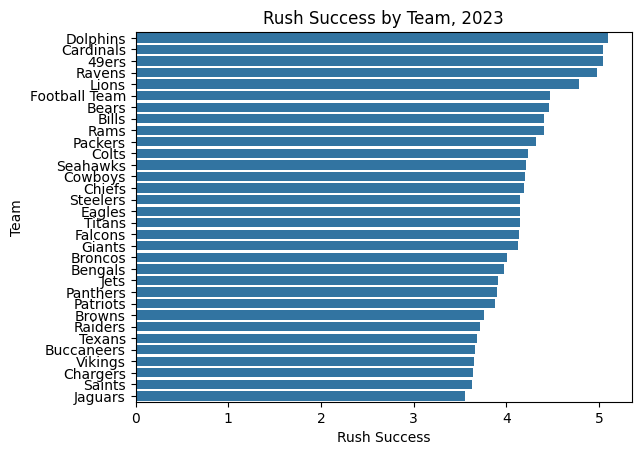

In [48]:
#barplot that shows rush sucess by team for the 2023 season
sns.barplot(data = all_teams_rush_success_2023.sort_values(by='rush_success', ascending=False), x = 'rush_success', y = 'name')
plt.title("Rush Success by Team, 2023")
plt.xlabel('Rush Success')
plt.ylabel('Team')
plt.show()

As I said before, the rush_success metric is a better metric to determine who was actually the best and worst rushing teams, per average, in each season. Looking at both these sets of graphs and the graphs displaying the rushing totals, we can come to some interesting conclusions:

- Our favorite rushing team, the Ravens, who I said before was undoubtedly the best rushing team in this time period, had by far the best rushing success in 2019 and 2020 as expected, but they were outside of the top three in 2023, despite leading the league in total rushing yards. In 2021, they were 5th in total rushing and outside of the top 5 in rushing success, likley due to Lamar Jackson being injured a handful of games that season.

- The Buccaneers, who I mentioned were bottom 10 in total rushing yards in each of the 5 seasons, actually were league average in rushing success in 2021, before plumenting to the worst rushing team in the league the following season. It is also interesting to note that this team won 11 games and won the superbowl in 2020, with a bottom 10 rushing team, and won 13 games in 2021 with a league average rushing team. In 2022 however, they only won 8 games (out of 17) and had the worst team rushing success this season. Tom Brady was the QB for all three of these teams and put up pretty insane numbers for a 40+ year old, something we will likely see when we look at the passing stats. That being said, it is only three seasons, but at a glance it looks like team rushing success positively correlates with winning games, more so than passing, but we will look into this further later.


Another little tidbit: 2021 was the first year that the NFL increased the number of regular season games from 16 to 17, which is another reason why effiecency stats are a little more reliable for analysis than counting (totals) stats.

In [67]:
#create a table that displays the difference in ranking for total rushing yards and rushing efficency for the 2019 season.

total_rush_with_rank = all_teams_total_rush_2019.copy()
total_rush_with_rank['rush_yds_rank'] = total_rush_with_rank['rush_yds'].rank(ascending=False, method='min')
rush_success_with_rank = all_teams_rush_success_2019.copy()
rush_success_with_rank['rush_success_rank'] = rush_success_with_rank['rush_success'].rank(ascending=False, method='min')

rush_rank_diff = pd.merge(total_rush_with_rank[['name', 'rush_yds', 'rush_yds_rank']], rush_success_with_rank[['name', 'rush_success', 'rush_success_rank']], on='name')
rush_rank_diff['rank_difference'] = rush_rank_diff['rush_yds_rank'] - rush_rank_diff['rush_success_rank']

rush_rank_diff.sort_values(by='rush_yds_rank')

,name,rush_yds,rush_yds_rank,rush_success,rush_success_rank,rank_difference
25,Ravens,3481,1.0,5.677782,1.0,0.0
0,49ers,2917,2.0,4.890653,4.0,-2.0
30,Titans,2726,3.0,5.005486,2.0,1.0
27,Seahawks,2374,4.0,4.521452,12.0,-8.0
31,Vikings,2290,5.0,4.236007,19.0,-14.0
29,Texans,2244,6.0,4.666341,7.0,-1.0
3,Bills,2226,7.0,4.560273,11.0,-4.0
11,Cowboys,2153,8.0,4.638386,8.0,0.0
10,Colts,2130,9.0,4.390462,14.0,-5.0
13,Eagles,2059,10.0,4.239348,18.0,-8.0


In [68]:
#create a table that displays the difference in ranking for total rushing yards and rushing efficency for the 2020 season.


total_rush_with_rank = all_teams_total_rush_2020.copy()
total_rush_with_rank['rush_yds_rank'] = total_rush_with_rank['rush_yds'].rank(ascending=False, method='min')
rush_success_with_rank = all_teams_rush_success_2020.copy()
rush_success_with_rank['rush_success_rank'] = rush_success_with_rank['rush_success'].rank(ascending=False, method='min')

rush_rank_diff = pd.merge(total_rush_with_rank[['name', 'rush_yds', 'rush_yds_rank']], rush_success_with_rank[['name', 'rush_success', 'rush_success_rank']], on='name')
rush_rank_diff['rank_difference'] = rush_rank_diff['rush_yds_rank'] - rush_rank_diff['rush_success_rank']

rush_rank_diff.sort_values(by='rush_yds_rank')

,name,rush_yds,rush_yds_rank,rush_success,rush_success_rank,rank_difference
25,Ravens,3457,1.0,5.634179,1.0,0.0
30,Titans,2741,2.0,5.091006,3.0,-1.0
5,Browns,2613,3.0,4.740905,7.0,-4.0
26,Saints,2492,4.0,4.630851,10.0,-6.0
20,Packers,2373,5.0,4.735285,8.0,-3.0
22,Patriots,2346,6.0,4.755756,6.0,0.0
31,Vikings,2283,7.0,4.903746,5.0,2.0
24,Rams,2278,8.0,4.340139,18.0,-10.0
7,Cardinals,2237,9.0,4.670911,9.0,0.0
10,Colts,2159,10.0,4.551314,11.0,-1.0


In [69]:
#create a table that displays the difference in ranking for total rushing yards and rushing efficency for the 2021 season.


total_rush_with_rank = all_teams_total_rush_2021.copy()
total_rush_with_rank['rush_yds_rank'] = total_rush_with_rank['rush_yds'].rank(ascending=False, method='min')
rush_success_with_rank = all_teams_rush_success_2021.copy()
rush_success_with_rank['rush_success_rank'] = rush_success_with_rank['rush_success'].rank(ascending=False, method='min')

rush_rank_diff = pd.merge(total_rush_with_rank[['name', 'rush_yds', 'rush_yds_rank']], rush_success_with_rank[['name', 'rush_success', 'rush_success_rank']], on='name')
rush_rank_diff['rank_difference'] = rush_rank_diff['rush_yds_rank'] - rush_rank_diff['rush_success_rank']

rush_rank_diff.sort_values(by='rush_yds_rank')

,name,rush_yds,rush_yds_rank,rush_success,rush_success_rank,rank_difference
13,Eagles,2810,1.0,5.114589,2.0,-1.0
30,Titans,2544,2.0,4.438887,9.0,-7.0
10,Colts,2540,3.0,5.123599,1.0,2.0
3,Bills,2492,4.0,5.071512,4.0,0.0
0,49ers,2491,5.0,4.260553,19.0,-14.0
25,Ravens,2479,6.0,4.750724,6.0,0.0
5,Browns,2471,7.0,5.083812,3.0,4.0
9,Chiefs,2382,8.0,4.744080,7.0,1.0
22,Patriots,2242,9.0,4.276234,18.0,-9.0
11,Cowboys,2196,10.0,4.405999,11.0,-1.0


In [70]:
#create a table that displays the difference in ranking for total rushing yards and rushing efficency for the 2022 season.


total_rush_with_rank = all_teams_total_rush_2022.copy()
total_rush_with_rank['rush_yds_rank'] = total_rush_with_rank['rush_yds'].rank(ascending=False, method='min')
rush_success_with_rank = all_teams_rush_success_2022.copy()
rush_success_with_rank['rush_success_rank'] = rush_success_with_rank['rush_success'].rank(ascending=False, method='min')

rush_rank_diff = pd.merge(total_rush_with_rank[['name', 'rush_yds', 'rush_yds_rank']], rush_success_with_rank[['name', 'rush_success', 'rush_success_rank']], on='name')
rush_rank_diff['rank_difference'] = rush_rank_diff['rush_yds_rank'] - rush_rank_diff['rush_success_rank']

rush_rank_diff.sort_values(by='rush_yds_rank')

,name,rush_yds,rush_yds_rank,rush_success,rush_success_rank,rank_difference
1,Bears,3014,1.0,5.473517,1.0,0.0
13,Eagles,2925,2.0,4.705472,8.0,-6.0
25,Ravens,2875,3.0,5.226659,2.0,1.0
16,Giants,2779,4.0,4.996719,4.0,0.0
0,49ers,2735,5.0,4.647262,10.0,-5.0
14,Falcons,2718,6.0,4.882905,5.0,1.0
11,Cowboys,2502,7.0,4.367350,16.0,-9.0
5,Browns,2490,8.0,4.705622,7.0,1.0
3,Bills,2402,9.0,5.084629,3.0,6.0
17,Jaguars,2377,10.0,4.846520,6.0,4.0


In [71]:
#create a table that displays the difference in ranking for total rushing yards and rushing efficency for the 2023 season.


total_rush_with_rank = all_teams_total_rush_2023.copy()
total_rush_with_rank['rush_yds_rank'] = total_rush_with_rank['rush_yds'].rank(ascending=False, method='min')
rush_success_with_rank = all_teams_rush_success_2023.copy()
rush_success_with_rank['rush_success_rank'] = rush_success_with_rank['rush_success'].rank(ascending=False, method='min')

rush_rank_diff = pd.merge(total_rush_with_rank[['name', 'rush_yds', 'rush_yds_rank']], rush_success_with_rank[['name', 'rush_success', 'rush_success_rank']], on='name')
rush_rank_diff['rank_difference'] = rush_rank_diff['rush_yds_rank'] - rush_rank_diff['rush_success_rank']

rush_rank_diff.sort_values(by='rush_yds_rank')

,name,rush_yds,rush_yds_rank,rush_success,rush_success_rank,rank_difference
25,Ravens,2971,1.0,4.974038,4.0,-3.0
19,Lions,2686,2.0,4.777945,5.0,-3.0
0,49ers,2655,3.0,5.043883,3.0,0.0
3,Bills,2573,4.0,4.401976,8.0,-4.0
1,Bears,2399,5.0,4.463493,7.0,-2.0
12,Dolphins,2384,6.0,5.096392,1.0,5.0
7,Cardinals,2365,7.0,5.044784,2.0,5.0
13,Eagles,2232,8.0,4.147235,16.0,-8.0
20,Packers,2184,9.0,4.320509,10.0,-1.0
9,Chiefs,2166,10.0,4.188809,14.0,-4.0


These tables diplay a teams ranking in total rushing yards, rushing success, and the difference in the rankings. This allows us to see exactly who the best rushing teams were even if they didn't have the most total yards and it allows us to see who didn't have the most success, even if they totaled a lot of yards.

So here are the biggest frauds (negaitve rank difference) and biggest gems (positive rank difference) for each season.

2019: The Vikings were the biggest frauds this season with a rank difference of -14; they were 5th in total rushing yards, but fell to 19th in rush success.
The Giants, Browns and Panthers all had a rank difference of at least +10, with all of them outside the top ten in yards but in the top ten in success.

2020: The Chargers, Rams and Buccaners all had at least -10 rank differnce this season, with the Chargers ranked 20th in yards but was actually the second worst successful rushing team in the league. The biggest gem was the Jaguars with a +16 rank difference with the 4th least total yards but 13th in success.

2021: The two biggest frauds this season were the 49ers and the Bengal, both with a rank difference of -14. This absolutely shocking for the 49ers because although they had a down year in 2020, ranking 18th in total rushing and 16th in success, they ranked top 5 in total rushing every other year and is considered one of the best rushing offenses (and offenses in general) during this time under Head Coach Kyle Shannahan. Despite the mostly high rankings in total rushing, they ranked outside the top 15 in rush success in consecutive seasons and only 10 in 2022, before returning to the top five in 2023. The Bengals on the other hand, are not suprising at all, ranking in the bottom 12 in rush success for all 5 years, likely due to the air raid offense lead by QB Joe Burrow.

The biggest gem this season was the Chargers, turing it around from the previous season where they had the worst rank differnce. They rank 23rd in total rushing yards, but they were top ten in rush success.

2022: The biggest fraud this season was the Commanders (Football Team), posing as a league average rushing team when they were actually close to the bottom 5 in rushing success. The biggest gem was the Raiders, ranking 19th in total yards but top 10 in success.

2023: The biggest fraud this season was the Browns who was top 15 in total rushing but bottom 10 in success. The biggest gem was the Commanders (Football Team), another team that turned it around from the previous season, with an astonoshing +22 rank difference with the 5th *least* rushing yards but just outside the top 5 in rushing success. The massive difference is very interesting, but even more so when you see that this team only won 4 games this season. This likely means that this team was losing a lot in their games, and when teams are losing, they are less likely to run the ball. So even though they appeared to have success running the ball, they might not have been able to afford running the ball due to trailing on the scoreboard. It's either that, or bad playcalling. Or both.

Another big gem this season was the Seahawks who ranked just behind the Commaders at 29th in total rushing yards but ranked 12th in success, a rank difference of +17! Now, this team won 9 games this season, barley missing out on the playoffs, so their explanation for such a big rank difference is likley different from the Commaders. We may have to look at their passing rankings to get a better idea of why this happened.

The most consistent teams are the Jets and Bengals who have some of the worst rushing offenses in this era and the Ravens who have the best rushing offense in this era. The Titans were consitently a top three rushing team until 2022 when their ranking dropped below league average. Considering they had Derrick Henry for all five of these seasons, it is a little bit of a mystery why their ranking fell so far after 2021.


In [73]:
rushing_2020[rushing_2020['name'] == 'Jaguars']

,name,rush_att,rush_yds,rush_avg,rush_tds,rush_success,fumbles,fumbles_lost
13,Jaguars,23,91,3.956522,0,3.956522,0,0
48,Jaguars,27,165,6.111111,1,6.259259,2,0
65,Jaguars,17,72,4.235294,2,4.470588,1,1
102,Jaguars,20,89,4.450000,0,4.450000,0,0
134,Jaguars,20,75,3.750000,0,3.350000,2,2
157,Jaguars,16,44,2.750000,1,2.750000,2,1
204,Jaguars,27,140,5.185185,1,5.185185,1,1
245,Jaguars,27,115,4.259259,2,4.555556,1,0
272,Jaguars,23,109,4.739130,0,4.739130,0,0
305,Jaguars,17,73,4.294118,0,4.294118,1,0


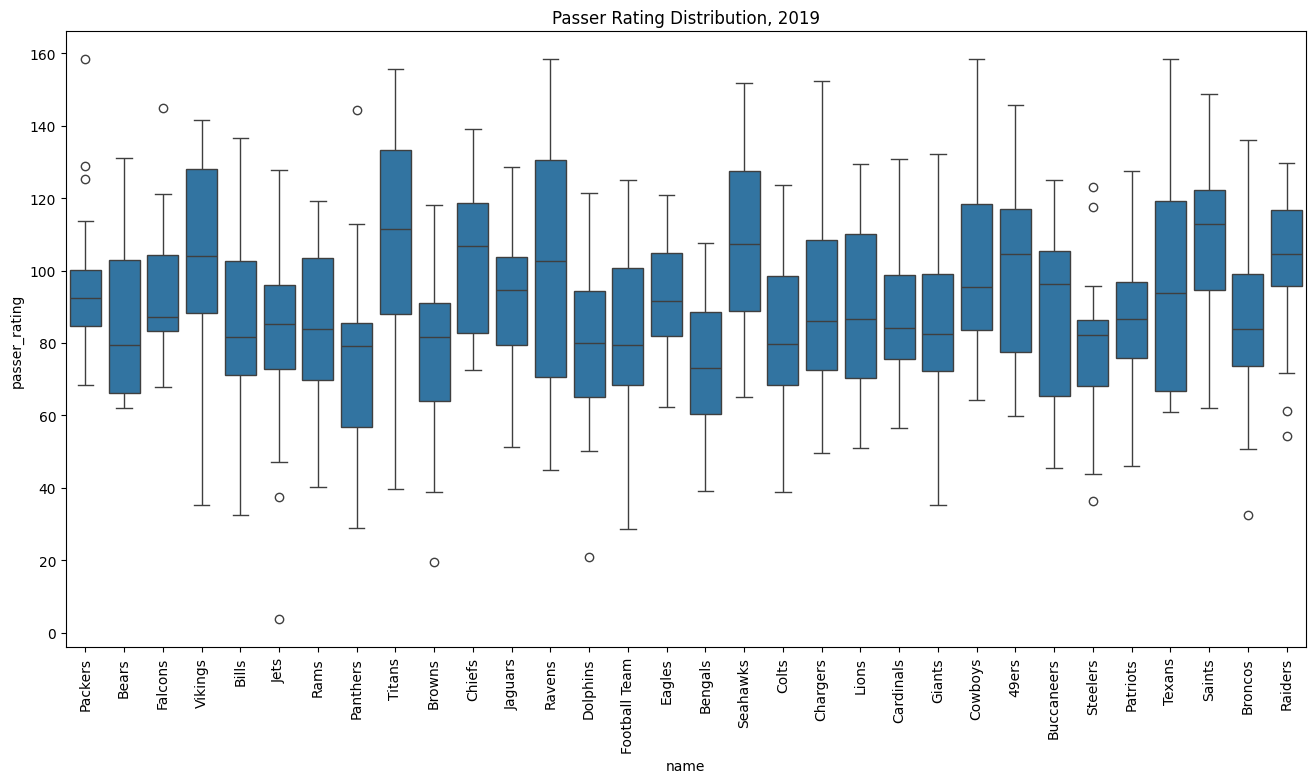

In [49]:
#distribution plot for passer rating by team

plt.figure(figsize=(16, 8))
sns.boxplot(data=passing_2019, x="name", y="passer_rating")
plt.title("Passer Rating Distribution, 2019")
plt.xticks(rotation=90)
plt.show()

Standard plot that shows distribuition of passerrating per game by team in the 2019 season. Another plot with a lot of variation and more outliers than the rushing plot. The following plots will diplay the same for the following seasons.

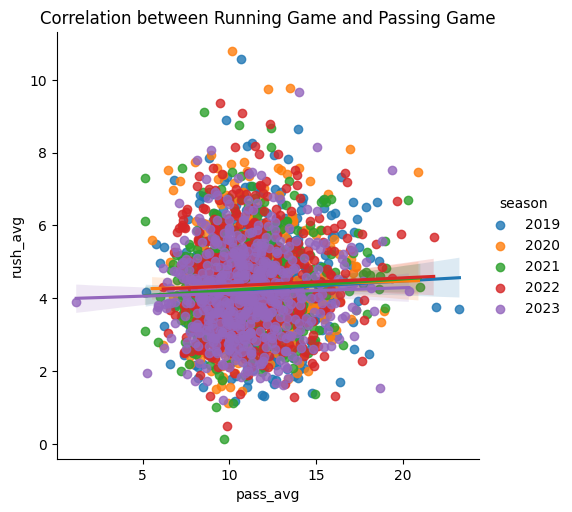

In [50]:
#Correlation between running game and passing game (linear regression)
sns.lmplot(data=stats, x='pass_avg', y='rush_avg', hue='season')
plt.title("Correlation between Running Game and Passing Game")
plt.show()

This plot displays the correlations between rushing average and passing average. The extremly messy data suggests that there is almost no correlation between rushing average and passing average and passing average is not a good predictor of rushing average, which is very surprising.

In [51]:
#Linear regression model, y = rush_avg, x = pass_avg)
model1 = smf.ols("rush_avg ~ pass_avg", data = stats) .fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               rush_avg   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     5.008
Date:                Tue, 28 Apr 2026   Prob (F-statistic):             0.0253
Time:                        15:41:01   Log-Likelihood:                -4615.1
No. Observations:                2776   AIC:                             9234.
Df Residuals:                    2774   BIC:                             9246.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.0166      0.116     34.716      0.000       3.790       4.243
pass_avg       0.0226      0.010      2.238      0.025       0.003       0.042
==============================================================================
Omnibus:                      208.875   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              301.554
Skew:                           0.614   Prob(JB):                     3.30e-66
Kurtosis:                       4.048   Cond. No.                         55.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

This regression test reinforces the claim that there is little to no correlation between rushing average and passing average and passing average is not a good predictor of rushing average.


- The coeffecient for pass_avg is 0.0226 meaning, a one unit increase in rush_avg is associated with 0.0226 change in pass_avg, assuming variables are held constant.
- Based on the low p-value of 0.025 we can determine that the "pass_avg" is statistcally significant.
- Based on the R-squared value of 0.002 we can conclude that rush average is not dependent on pass average.

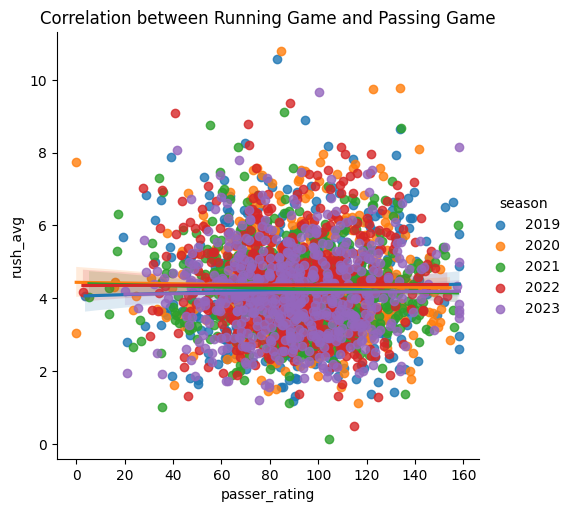

In [52]:
#Correlation between running game and passing game (linear regression)
sns.lmplot(data=stats, x='passer_rating', y='rush_avg', hue='season')
plt.title("Correlation between Running Game and Passing Game")
plt.show()

In [53]:
model1 = smf.ols("rush_avg ~ passer_rating", data = stats) .fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               rush_avg   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.004997
Date:                Tue, 28 Apr 2026   Prob (F-statistic):              0.944
Time:                        15:41:02   Log-Likelihood:                -4617.6
No. Observations:                2776   AIC:                             9239.
Df Residuals:                    2774   BIC:                             9251.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.2637      0.089     47.715      0.000       4.088       4.439
passer_rating  6.677e-05      0.001      0.071      0.944      -0.002       0.002
==============================================================================
Omnibus:                      209.266   Durbin-Watson:                   1.978
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              301.527
Skew:                           0.616   Prob(JB):                     3.34e-66
Kurtosis:                       4.044   Cond. No.                         349.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Correlation between rush_avg and passer rating.

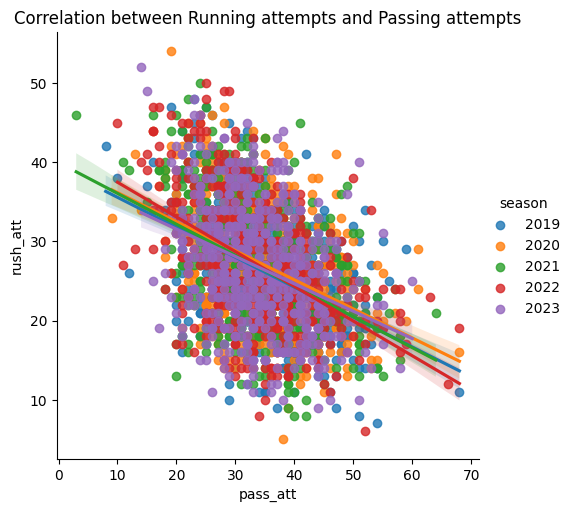

In [54]:
sns.lmplot(data=stats, x='pass_att', y='rush_att', hue='season')
plt.title("Correlation between Running attempts and Passing attempts")
plt.show()

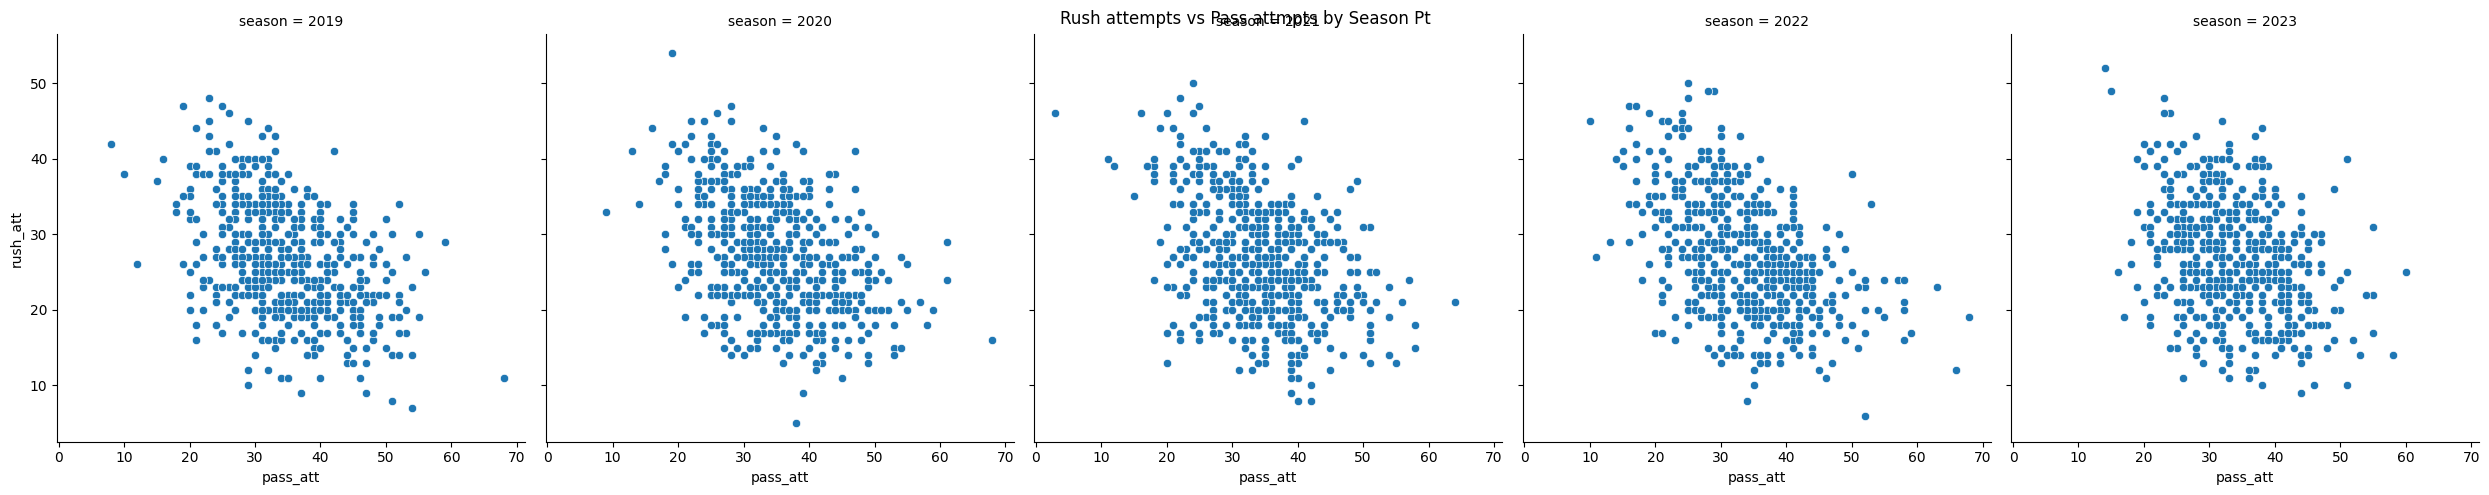

In [55]:
sns.relplot(data=stats, x="pass_att", y="rush_att", col="season")
plt.suptitle("Rush attempts vs Pass attmpts by Season Pt")
plt.show()

In [56]:
model1 = smf.ols("rush_att ~ pass_att", data = stats) .fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               rush_att   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     608.0
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          1.51e-121
Time:                        15:41:05   Log-Likelihood:                -9298.0
No. Observations:                2776   AIC:                         1.860e+04
Df Residuals:                    2774   BIC:                         1.861e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9672      0.553     72.310      0.000      38.883      41.051
pass_att      -0.3857      0.016    -24.657      0.000      -0.416      -0.355
==============================================================================
Omnibus:                       15.677   Durbin-Watson:                   2.532
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               12.284
Skew:                           0.071   Prob(JB):                      0.00215
Kurtosis:                       2.707   Cond. No.                         149.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [57]:
drives_agg = drives_full.groupby('season')[['pass_plays', 'rush_plays']].mean().reset_index()
display(drives_agg.head())

,season,pass_plays,rush_plays
0,2018,3.323082,2.318068
1,2019,3.321093,2.338364
2,2020,3.442693,2.469762
3,2021,3.398148,2.459714
4,2022,3.298058,2.500485


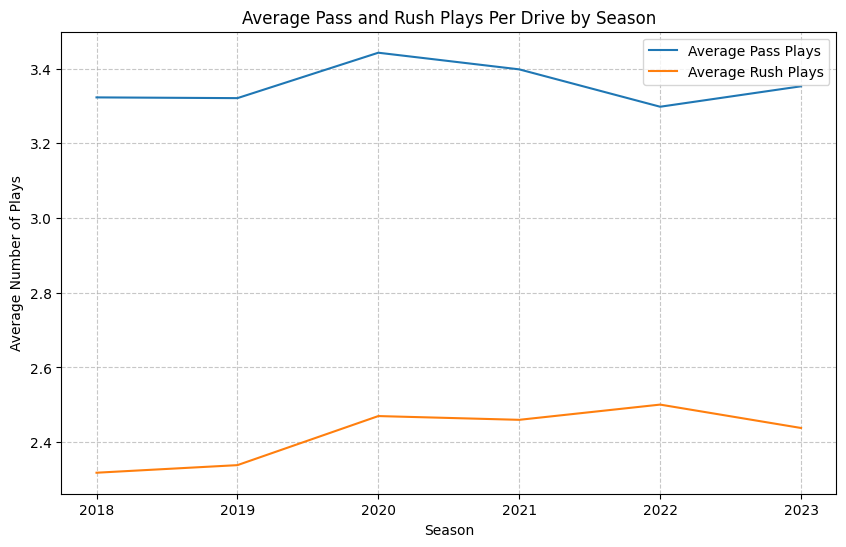

In [58]:
#Lineplot that shows pass plays and rush plays per drive by year
plt.figure(figsize=(10, 6))
sns.lineplot(data=drives_agg, x='season', y='pass_plays', label='Average Pass Plays')
sns.lineplot(data=drives_agg, x='season', y='rush_plays', label='Average Rush Plays')
plt.title('Average Pass and Rush Plays Per Drive by Season')
plt.xlabel('Season')
plt.ylabel('Average Number of Plays')
plt.xticks(drives_agg['season'].unique())
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [59]:
season = [2019, 2019, 2020, 2020, 2021, 2021, 2022, 2022, 2023, 2023]
drive_avg = [3.32, 2.39, 3.44, 2.47, 3.40, 2.46, 3.30, 2.50, 3.35, 2.48]
play_type = ['Average_pass_play', 'Average_rush_play', 'Average_pass_play', 'Average_rush_play', 'Average_pass_play', 'Average_rush_play', 'Average_pass_play', 'Average_rush_play', 'Average_pass_play', 'Average_rush_play']

drives_avg = pd.DataFrame({'season': season, 'drive_avg': drive_avg, 'play_type': play_type})
drives_avg

,season,drive_avg,play_type
0,2019,3.32,Average_pass_play
1,2019,2.39,Average_rush_play
2,2020,3.44,Average_pass_play
3,2020,2.47,Average_rush_play
4,2021,3.40,Average_pass_play
5,2021,2.46,Average_rush_play
6,2022,3.30,Average_pass_play
7,2022,2.50,Average_rush_play
8,2023,3.35,Average_pass_play
9,2023,2.48,Average_rush_play


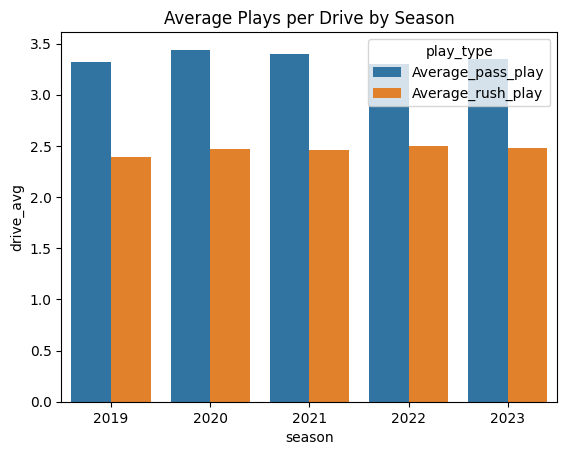

In [60]:
#Grouped barplot that shows pass plays and rush plays per drive by year
sns.barplot( x = 'season', y = 'drive_avg', hue = 'play_type', data = drives_avg)
plt.title("Average Plays per Drive by Season")
plt.show()

I think the only notable thing about these graphs is that in 2019 there were less overall plays in a drive than the other years, But as far as notable trends go, there isn't enough data here to make a solid conclusion.

In [61]:
drives_2 =drives.copy('drives')
drives_2['points'] = drives_2['points'].astype('string')
drives_2.insert(23, 'result', drives_2['points'])

In [62]:
drives_2.replace({'result': {'-2': 'saftey', '0': 'no points', '3': 'FG', '7': 'TD'}}, inplace=True)
drives_2.head()

,season,tm_market,tm_name,tm_alias,opp_nano,opp_market,opp_name,opp_alias,tm_on_offense,tm_on_defense,...,penalties,pass_plays,rush_plays,total_plays,points,result,drive_start,drive_end,clean,boxscore_stats_link
0,2023,Minnesota,Vikings,MIN,IwSI92ZDKoazn,San Francisco,49ers,SF,MIN,SF,...,0,6,1,7,0,no points,Kickoff,Punt,1,https://www.pro-football-reference.com/boxscor...
1,2023,Minnesota,Vikings,MIN,IwSI92ZDKoazn,San Francisco,49ers,SF,SF,MIN,...,0,3,4,7,0,no points,Punt,Interception,1,https://www.pro-football-reference.com/boxscor...
2,2023,Minnesota,Vikings,MIN,IwSI92ZDKoazn,San Francisco,49ers,SF,MIN,SF,...,1,4,5,10,0,no points,Interception,Missed FG,1,https://www.pro-football-reference.com/boxscor...
3,2023,Minnesota,Vikings,MIN,IwSI92ZDKoazn,San Francisco,49ers,SF,SF,MIN,...,0,5,0,5,0,no points,Missed FG,Interception,1,https://www.pro-football-reference.com/boxscor...
4,2023,Minnesota,Vikings,MIN,IwSI92ZDKoazn,San Francisco,49ers,SF,MIN,SF,...,0,0,1,1,0,no points,Interception,End of Game,1,https://www.pro-football-reference.com/boxscor...


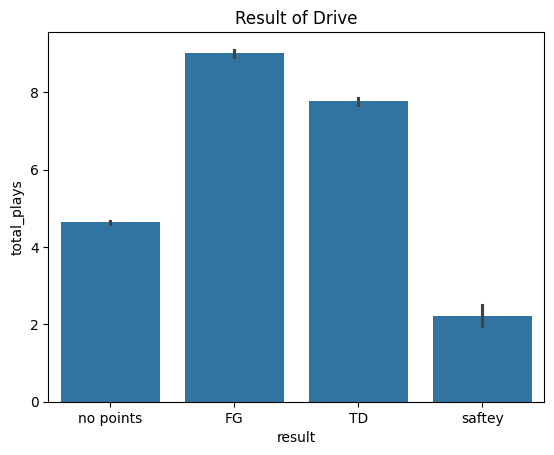

In [63]:
#barplot that shows the result of drives
sns.barplot( x = 'result', y = 'total_plays', data = drives_2)
plt.title("Result of Drive")
plt.show()